In [13]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ks_2samp
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import false_discovery_control
from PIL import Image


In [14]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

In [61]:
def fig_to_panels(fig, axes, output_dir):
    # Save individual panels of a figure 
    os.makedirs(output_dir, exist_ok=True)
    
    for panel_name, ax in axes.items():
        # Extract the panel title
        panel_title = ax.get_title()

        # Sanitize the panel title to use in filenames
        safe_title = panel_title.replace(" ", "_").replace("/", "_").replace("\n", "_").lower()

        # Create the filename for the current panel
        output_file = os.path.join(output_dir,safe_title)

        # Adjust the bounding box to include everything (labels, titles, etc.)
        extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

        # Save the individual panel using the adjusted bounding box
        fig.savefig(output_file + '.pdf', bbox_inches=extent, dpi=300)
        fig.savefig(output_file + '.png', bbox_inches=extent)

        print(f"Saved panel '{panel_title}' to {output_file}")

In [39]:
# Function to run the KS test and return the KS statistic and p-value
def get_pvals_stats(data, condition):
    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']

    # Perform KS test
    ks_stat, p_value = ks_2samp(ligand_values, gpcr_values)
    
    return ks_stat, p_value


In [40]:
def plot_cdf_with_ks(
    data,
    condition,
    ax,
    ks_stat,
    adjusted_p_value,
    color_ligand,
    color_gpcr, 
    ylim=None,
    xlim=None,    
    text_coords=(0.35, 0.85),
    text_ha='right',
):
    # Optionally set limits before plotting
    if ylim:
        ax.set_ylim(ylim)
    if xlim:
        ax.set_xlim(xlim)
        
    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']

    # Plot the ECDFs
    sns.ecdfplot(gpcr_values, ax=ax, color=color_gpcr, label='G-Protein', linewidth=2, zorder=1)
    sns.ecdfplot(ligand_values, ax=ax, color=color_ligand, label='Ligand', linewidth=2, zorder=2)

    # Highlight the maximum difference (D-statistic)
    cdf_ligand = np.sort(ligand_values)
    cdf_gpcr = np.sort(gpcr_values)
    all_values = np.sort(np.unique(np.concatenate((cdf_ligand, cdf_gpcr))))
    cdf_ligand_y = np.searchsorted(cdf_ligand, all_values, side='right') / len(cdf_ligand)
    cdf_gpcr_y = np.searchsorted(cdf_gpcr, all_values, side='right') / len(cdf_gpcr)
    max_diff_index = np.argmax(np.abs(cdf_ligand_y - cdf_gpcr_y))

    x_max_diff = all_values[max_diff_index]
    y1_max_diff = cdf_ligand_y[max_diff_index]
    y2_max_diff = cdf_gpcr_y[max_diff_index]
    midpoint_y = (y1_max_diff + y2_max_diff) / 2

    head_width  = 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])
    head_length = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])

    # D-statistic lines and arrows
    ax.vlines(x_max_diff, y1_max_diff, y2_max_diff, color='k', linestyle='-', lw=1.5)
    ax.arrow(x_max_diff, y1_max_diff, 0, y2_max_diff - y1_max_diff, 
             color='k', lw=1.5, head_width=head_width, head_length=head_length, length_includes_head=True, zorder=10)
    ax.arrow(x_max_diff, y2_max_diff, 0, y1_max_diff - y2_max_diff, 
             color='k', lw=1.5, head_width=head_width, head_length=head_length, length_includes_head=True, zorder=10)

    # Determine significance marker for p-value
    if adjusted_p_value < 0.001:
        significance = '***'
    elif adjusted_p_value < 0.01:
        significance = '**'
    elif adjusted_p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'  # Not significant

    # D-statistic annotation with configurable position and alignment
    text_x, text_y = text_coords
    ax.text(
        text_x, text_y,
        f'D = {ks_stat:.2f}\np = {adjusted_p_value:.1e}\n{significance}',
        fontsize=fs, ha=text_ha, va='center',
        transform=ax.transAxes,
    )

    # Draw connector line to D-stat
    max_diff_axis_rel = ax.transData.transform((x_max_diff, midpoint_y))
    max_diff_axis_rel_x, max_diff_axis_rel_y = ax.transAxes.inverted().transform(max_diff_axis_rel)
    direction_x = max_diff_axis_rel_x - text_x
    direction_y = max_diff_axis_rel_y - text_y
    offset_x = direction_x * 0.75
    offset_y = direction_y * 0.75
    start_x = text_x + offset_x
    start_y = text_y + offset_y
    end_x = max_diff_axis_rel_x - offset_x
    end_y = max_diff_axis_rel_y - offset_y
    ax.plot([start_x, end_x], [start_y, end_y], color='k', lw=1, linestyle='-', zorder=9, transform=ax.transAxes)

    # Axes formatting
    ax.set_title(f'{condition}', fontsize=fs)
    ax.set_xlabel('Value', fontsize=fs)
    ax.set_ylabel('Cumulative Probability', fontsize=fs)
    ax.tick_params(labelsize=fs, direction='out')
    ax.legend(fontsize=fs, loc='lower right')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(bottom=True, left=True)  # Ensure ticks are visible
    ax.spines[['right', 'top']].set_visible(False)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    # Set ticks at a specific distance (e.g., 0.5 units)
    tick_distance = 0.5

    # Get the current axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create tick positions based on the tick distance, starting from the lowest value within the limits
    x_ticks = np.arange(np.floor(xlim[0] / tick_distance) * tick_distance, 
                        np.ceil(xlim[1] / tick_distance) * tick_distance + tick_distance, 
                        tick_distance)
    y_ticks = np.arange(np.floor(ylim[0] / tick_distance) * tick_distance, 
                        np.ceil(ylim[1] / tick_distance) * tick_distance + tick_distance, 
                        tick_distance)

    # Filter ticks to ensure they are within the current axis limits
    x_ticks = x_ticks[(x_ticks >= xlim[0]) & (x_ticks <= xlim[1])]
    y_ticks = y_ticks[(y_ticks >= ylim[0]) & (y_ticks <= ylim[1])]

    # Apply the calculated ticks
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)



# GPCRS - Gprot couplings

In [15]:
# Read GPCRs
gpcrs = pd.read_csv('/home/fraimondi/BIOINFO1_BK/francesco/GPCR/gpcrs_genes.txt')['Symbol'].values

# Read ligands
lr = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv')
gpcrs_lr = lr[lr.receptor.isin(gpcrs)]
gpcrs_ligands = list(set(gpcrs_lr.ligand))
lr_pairs = gpcrs_lr.set_index(['ligand', 'receptor']).index

# Read G-Proteins coupling
gprots_couplings = pd.read_csv('/home/lnemati/resources/gpcr_couplings/gpcr_couplings.csv')
gprots = list(set(gprots_couplings.gprot))

gprots_couplings = gprots_couplings.query('n_sources >= 3')
gprots_couplings = gprots_couplings.query('type != "precogx_only"')
gprots_couplings.set_index('gpcr', inplace=True, drop=False)
gprots_couplings.index.name = None
gprots_couplings = gprots_couplings.groupby('gpcr')['gprot'].apply(list)

gpcr_gprot_pairs = (
    gprots_couplings
    .explode()                # expand lists into rows
    .rename('gprot')
    .reset_index()            # gpcr becomes a column
    .set_index(['gpcr', 'gprot'])
    .index
)


In [16]:
# Get G-Proteins, GPCRs and their ligands
gpcrs_genes = list(set(gpcrs) | set(gprots) | set(lr.ligand.values) | set(lr.receptor.values))

# Read Coevolution

In [17]:
#path = '/projects/bioinformatics/DB/coevolution/CancerTracer/all_mutations'
path = '/projects/bioinformatics/DB/coevolution/CancerTracer/only_non_synonym_amp_del'

print('t')
coev_trunk   = pd.read_csv(os.path.join(path, 'trunk' , 'normalized_difference.csv'), index_col=0)
print('b')
coev_branch  = pd.read_csv(os.path.join(path, 'branch', 'normalized_difference.csv'), index_col=0)
print('l')
coev_leaf    = pd.read_csv(os.path.join(path, 'leaf'  , 'normalized_difference.csv'), index_col=0)

normal_path = '/projects/bioinformatics/DB/coevolution/orthology'
print('n')
coev_normal   = pd.read_csv(os.path.join(normal_path, 'normalized_difference.csv'), index_col=0)

t
b
l
n


In [18]:
def build_coev_df(coev_df, gprots_couplings, lr, condition_label):
    df = pd.DataFrame(columns=['gpcr', 'interactor', 'interactor_type', 'condition', 'value'])

    # --- GPCR - G Protein ---
    for gpcr in gprots_couplings.index.intersection(coev_df.index):
        couplings = coev_df.index.intersection(gprots_couplings.loc[gpcr])
        values = coev_df.loc[gpcr, couplings].to_frame(name='value')
        values['gpcr'] = gpcr
        values['interactor'] = values.index
        values['interactor_type'] = 'G-Protein'
        values['tissue'] = 'Co-Evolution'
        values['condition'] = condition_label
        values['value_type'] = 'Co-Evolution'

        df = pd.concat([df, values])

    # --- GPCR - Ligand ---
    for gpcr in coev_df.index.intersection(lr.receptor.unique()):
        ligands = coev_df.index.intersection(lr[lr['receptor'] == gpcr].ligand.unique())
        values = coev_df.loc[gpcr, ligands].to_frame(name='value')
        values['gpcr'] = gpcr
        values['interactor'] = values.index
        values['interactor_type'] = 'Ligand'
        values['tissue'] = 'Co-Evolution'
        values['condition'] = condition_label
        values['value_type'] = 'Co-Evolution'

        df = pd.concat([df, values])

    return df.reset_index(drop=True)

In [19]:
df_normal  = build_coev_df(coev_normal,  gprots_couplings, lr, 'Normal Co-Evolution')
df_trunk   = build_coev_df(coev_trunk,   gprots_couplings, lr, 'Trunk Co-Evolution')
df_branch  = build_coev_df(coev_branch,  gprots_couplings, lr, 'Branch Co-Evolution')
df_leaf    = build_coev_df(coev_leaf,    gprots_couplings, lr, 'Leaf Co-Evolution')
df_coev = pd.concat([df_normal, df_trunk, df_branch, df_leaf])

/var/tmp/pbs.437089.pbs01/ipykernel_236867/194945625.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, values])
/var/tmp/pbs.437089.pbs01/ipykernel_236867/194945625.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, values])
/var/tmp/pbs.437089.pbs01/ipykernel_236867/194945625.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA column

In [20]:
df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/gpcrs/all_gpcr_interactions.csv')
#df = df[df['subtissue'] != 'testis']
df.query('not (subtissue == "testis" and condition == "normal")')
df = df.groupby(['gpcr', 'interactor', 'condition', 'interactor_type', 'tissue', 'value_type'], as_index=False)['value'].mean()
df = df.query('value_type in ["correlation", "jaccard"]')
df['condition'] =df['condition'].replace({'normal': 'Normal Co-Expression', 'tumor': 'Tumor Co-Expression'})

In [21]:
df = pd.concat([df, df_coev])

# Supplementary Fig.

In [22]:
#ncoev_df = df.query('condition == "Normal Co-Evolution"')
#df = pd.concat([ncoev_df, pd.read_csv('/home/lnemati/pathway_crosstalk/results/gpcrs/all_gpcr_interactions.csv')])

#df.query('not (subtissue == "testis" and condition == "normal")')
#df = df.groupby(['gpcr', 'interactor', 'condition', 'interactor_type', 'tissue', 'value_type'], as_index=False)['value'].mean()
#df = df.query('value_type in ["correlation", "Co-Evolution"]')
#df = df.query('value_type in ["adjacency", "Co-Evolution"]')
#df['condition'] =df['condition'].replace({'normal': 'Normal Co-Expression', 'tumor': 'Tumor Co-Expression'})

In [27]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df['interaction'] = df.gpcr + '-' + df.interactor

def calc_and_plot(groupby_col, category_name):
    print(f'\n{category_name}')
    
    ddf = df.copy()
    if category_name in ['Ligand', 'G-Protein']:
        ddf = ddf.query('interactor_type == @category_name')
    
    # Get series for each condition
    ncoexpr = ddf.query('condition == "Normal Co-Expression"').groupby(groupby_col)['value'].mean()
    tcoexpr = ddf.query('condition == "Tumor Co-Expression"').groupby(groupby_col)['value'].mean()
    ncoev = ddf.query('condition == "Co-Evolution"').groupby(groupby_col)['value'].mean()

    # Shared indices for each pair
    n_t_shared = ncoexpr.index.intersection(tcoexpr.index)
    n_coev_shared = ncoexpr.index.intersection(ncoev.index)
    t_coev_shared = tcoexpr.index.intersection(ncoev.index)

    # Correlations and p-values
    def corr_p(x, y):
        if len(x) < 2:  # Not enough points for correlation
            return float('nan'), float('nan')
        return pearsonr(x, y)

    r_n_t, p_n_t = corr_p(ncoexpr[n_t_shared], tcoexpr[n_t_shared])
    r_n_coev, p_n_coev = corr_p(ncoexpr[n_coev_shared], ncoev[n_coev_shared])
    r_t_coev, p_t_coev = corr_p(tcoexpr[t_coev_shared], ncoev[t_coev_shared])

    print(f"Normal vs Tumor Co-Expression: r = {r_n_t:.3f}, p = {p_n_t:.2e}")
    print(f"Normal Co-Expression vs Coevolution: r = {r_n_coev:.3f}, p = {p_n_coev:.2e}")
    print(f"Tumor Co-Expression vs Coevolution: r = {r_t_coev:.3f}, p = {p_t_coev:.2e}")

    # Plotting
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{category_name} Correlations')

    axs[0].scatter(ncoexpr[n_t_shared], tcoexpr[n_t_shared], alpha=0.6)
    axs[0].set_title('Normal vs Tumor Co-Expression')
    axs[0].set_xlabel('Normal Co-Expression')
    axs[0].set_ylabel('Tumor Co-Expression')

    axs[1].scatter(ncoexpr[n_coev_shared], ncoev[n_coev_shared], alpha=0.6)
    axs[1].set_title('Normal Co-Expression vs Coevolution')
    axs[1].set_xlabel('Normal Co-Expression')
    axs[1].set_ylabel('Co-Evolution')

    axs[2].scatter(tcoexpr[t_coev_shared], ncoev[t_coev_shared], alpha=0.6)
    axs[2].set_title('Tumor Co-Expression vs Coevolution')
    axs[2].set_xlabel('Tumor Co-Expression')
    axs[2].set_ylabel('Co-Evolution')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## GPCRs grouped by 'gpcr'
#calc_and_plot('gpcr', 'GPCRs')
## Ligands grouped by 'interactor'
#calc_and_plot('interactor', 'Ligand')
## G-Proteins grouped by 'interactor'
#calc_and_plot('interactor', 'G-Protein')


In [28]:
import pandas as pd
from scipy.stats import pearsonr

df['interaction'] = df.gpcr + '-' + df.interactor

results = []

def compute_correlations_by_tissue(groupby_col, category_name, result_label):
    ddf = df.copy()
    ddf.query('interactor_type != "G-Protein"')
    if category_name in ['Ligand', 'G-Protein']:
        ddf = ddf.query('interactor_type == @category_name')

    tissues = ddf.query('condition != "Co-Evolution"')['tissue'].unique()
    
    for tissue in tissues:
        # Filter data
        ncoexpr = ddf.query('condition == "Normal Co-Expression" and tissue == @tissue').groupby(groupby_col)['value'].mean()
        tcoexpr = ddf.query('condition == "Tumor Co-Expression" and tissue == @tissue').groupby(groupby_col)['value'].mean()
        ncoev = ddf.query('condition == "Normal Co-Evolution"').groupby(groupby_col)['value'].mean()

        # Shared indices
        n_coev_shared = ncoexpr.index.intersection(ncoev.index)
        t_coev_shared = tcoexpr.index.intersection(ncoev.index)

        def corr_p(x, y):
            if len(x) < 2:
                return float('nan'), float('nan')
            return pearsonr(x, y, alternative='greater')

        # Correlations
        r_n_coev, p_n_coev = corr_p(ncoexpr[n_coev_shared], ncoev[n_coev_shared])
        r_t_coev, p_t_coev = corr_p(tcoexpr[t_coev_shared], ncoev[t_coev_shared])

        # Append to results
        results.append({
            'tissue': tissue,
            'type': result_label,
            'normal_corr': r_n_coev,
            'normal_p': p_n_coev,
            'tumor_corr': r_t_coev,
            'tumor_p': p_t_coev
        })

# Run for each category
compute_correlations_by_tissue('gpcr', 'GPCRs', 'gpcr')
compute_correlations_by_tissue('interactor', 'Ligand', 'ligand')
#compute_correlations_by_tissue('interactor', 'G-Protein', 'gprot')

# Convert to DataFrame
result_df = pd.DataFrame(results)
result_df.loc[~result_df['normal_p'].isna(), 'normal_p'] = false_discovery_control(result_df.loc[~result_df['normal_p'].isna(), 'normal_p'])
result_df.loc[~result_df['tumor_p'].isna(), 'tumor_p'] = false_discovery_control(result_df.loc[~result_df['tumor_p'].isna(), 'tumor_p'])

In [30]:
#result_df.sort_values(by='tumor_p').to_csv('/home/lnemati/pathway_crosstalk/results/gpcrs/gene_scores.csv')
#result_df.sort_values(by='tumor_p').to_csv('/home/lnemati/pathway_crosstalk/results/supplementary/gene_scores.csv')

In [32]:
result_df[result_df['tumor_p'] < 0.05]['type'].value_counts()

# OLD
#type
#ligand    24
#gpcr       5
#Name: count, dtype: int64

type
ligand    22
gpcr      17
Name: count, dtype: int64

In [146]:
result_df[result_df['tumor_p'] < 0.05].tissue.nunique()

# OLD 24

22

In [33]:
result_df.sort_values(by='tumor_corr', ascending=False).dropna().head(30).query('tissue == "breast"')

# OLD
# tissue 	type 	normal_corr 	normal_p 	tumor_corr 	tumor_p
# 47 	breast 	ligand 	0.181533 	0.276202 	0.270157 	0.006020
# 8 	breast 	gpcr 	-0.010963 	0.738848 	0.235596 	0.015427

,tissue,type,normal_corr,normal_p,tumor_corr,tumor_p
8,breast,gpcr,0.082343,0.389811,0.313466,0.002526
48,breast,ligand,0.221551,0.098811,0.233663,0.010263


In [48]:
result_df.query('tissue == "kidney"')

,tissue,type,normal_corr,normal_p,tumor_corr,tumor_p
25,kidney,gpcr,0.034897,0.529106,0.097517,0.141921
58,kidney,ligand,0.135895,0.251440,0.373720,0.000111


In [34]:
df_original = df.copy()

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import matplotlib.patheffects as path_effects
from decimal import Decimal
from adjustText import adjust_text

fs = 14

def plot_top_tissues(df, category, condition='tumor', top_n=5, groupby_col='gpcr', color='C0'):
    if category not in ['gpcr', 'ligand', 'gprot']:
        raise ValueError("category must be one of: 'gpcr', 'ligand', 'gprot'")
    if condition not in ['tumor', 'normal']:
        raise ValueError("condition must be 'tumor' or 'normal'")

    r_col = f'{condition}_corr'
    p_col = f'{condition}_p'

    filtered = df[(df['type'] == category) & df[r_col].notna()].copy()
    top_tissues = filtered.sort_values(r_col, ascending=False).head(top_n)['tissue'].values

    ddf = df_original.copy()
    if category == 'ligand':
        ddf = ddf.query('interactor_type == "Ligand"')
        name = 'Ligands'
    elif category == 'gprot':
        ddf = ddf.query('interactor_type == "G-Protein"')
        name = 'G Proteins'
    else:
        name = 'GPCRs'

    for tissue in top_tissues:
        print(tissue)
        # Get co-expression and coevolution values exactly as in correlation calculation
        coexpr = ddf.query(f'condition == "{condition.capitalize()} Co-Expression" and tissue == @tissue').groupby(groupby_col)['value'].mean()
        coev = ddf.query('condition == "Normal Co-Evolution"').groupby(groupby_col)['value'].mean()

        shared = coexpr.index.intersection(coev.index)
        x = coexpr[shared]
        y = coev[shared]

        # Get stored correlation and p-value from df for this tissue
        r = filtered.loc[filtered['tissue'] == tissue, r_col].values[0]
        p = filtered.loc[filtered['tissue'] == tissue, p_col].values[0]

        
        # Fit regression line
        fit = np.polyfit(x, y, 1)
        fit_fn = np.poly1d(fit)
        x_sorted = np.sort(x)

        # Plot
        fig, ax = plt.subplots(figsize=(7.5, 7.5))
        scatter = ax.scatter(x, y, alpha=1, color=color, lw=0.5, edgecolor='k')
        ax.plot(x_sorted, fit_fn(x_sorted), color='black', linestyle='--', lw=1)

        # Identify top genes by coexpression and coevolution
        top_labels = 10
        top_x = x.sort_values(ascending=False).head(top_labels)
        top_y = y.sort_values(ascending=False).head(top_labels)
        to_label = top_x.index.union(top_y.index)

        # Add labels only to selected genes
        texts = []
        for label in to_label:
            texts.append(
                ax.text(
                    x[label], y[label], label, fontsize=9, alpha=1,
                    color='k',
                    path_effects=[
                        path_effects.Stroke(linewidth=1, foreground='white'),
                        path_effects.Normal()
                    ]
                )
            )


        # Adjust text positions to avoid overlap
        adjust_text(texts, ax=ax, explode=(7,7), expand=(1,1), force_text=(10.,10.), arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

        ax.set_title(f"{tissue.title().replace('_', ' ')} - {name}")
        ax.set_xlabel(f"{condition.capitalize()} Co-Expression (Average Correlation)", fontsize=fs)
        ax.set_ylabel("Co-Evolution (Average Jaccard Index)", fontsize=fs)
        
        p_str = f"{Decimal(p):.1e}"  # Use Decimal to avoid floating point artifacts
        ax.text(
            0.7, 0.05, f"r = {r:.2f}\np = {p_str}",
            transform=ax.transAxes,
            fontsize=14,
            verticalalignment='bottom',
            color='k',
            path_effects=[
                path_effects.Stroke(linewidth=1, foreground='white'),
                path_effects.Normal()
            ]
        )
        
        #plt.tight_layout()
        plt.show()

#plot_top_tissues(result_df, category='ligand', condition='tumor', top_n=3, groupby_col='interactor', color=tcolor)
#plot_top_tissues(result_df, category='gpcr', condition='normal', top_n=3, groupby_col='interactor', color=ncolor)

In [63]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import matplotlib.patheffects as path_effects
import string
from adjustText import adjust_text

fs = 14

def plot_tissue_panel(df, tissue_category_pairs, colors=('C0', 'C1')):
    n_cols = len(tissue_category_pairs)
    fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 10))  # No shared axes
    panel_labels = list(string.ascii_uppercase)  # ['A', 'B', 'C', ..., 'Z']
    label_idx = 0

    for col_idx, (tissue, category) in enumerate(tissue_category_pairs):
        for row_idx, condition in enumerate(['tumor', 'normal']):
            ax = axes[row_idx, col_idx]

            # Dynamic groupby_col
            if category in ['ligand', 'gprot']:
                groupby_col = 'interactor'
            elif category == 'gpcr':
                groupby_col = 'gpcr'
            else:
                raise ValueError("Category must be one of: 'ligand', 'gprot', 'gpcr'")

            # Prep df
            r_col = f'{condition}_corr'
            p_col = f'{condition}_p'
            filtered = df[(df['type'] == category) & (df['tissue'] == tissue) & df[r_col].notna()]
            ddf = df_original.copy()

            if category == 'ligand':
                ddf = ddf.query('interactor_type == "Ligand"')
                name = 'Ligands'
            elif category == 'gprot':
                ddf = ddf.query('interactor_type == "G-Protein"')
                name = 'G Proteins'
            else:
                name = 'GPCRs'

            # Get coexpression (y-axis) and coevolution (x-axis)
            coexpr = ddf.query(f'condition == "{condition.capitalize()} Co-Expression" and tissue == @tissue').groupby(groupby_col)['value'].mean()
            coev = ddf.query('condition == "Normal Co-Evolution"').groupby(groupby_col)['value'].mean()
            shared = coexpr.index.intersection(coev.index)
            x = coev[shared]
            y = coexpr[shared]

            # Regression
            fit = np.polyfit(x, y, 1)
            fit_fn = np.poly1d(fit)
            x_sorted = np.sort(x)

            # Plot points
            ax.scatter(x, y, alpha=1, color=colors[row_idx], lw=0.5, edgecolor='k')
            ax.plot(x_sorted, fit_fn(x_sorted), color='black', linestyle='--', lw=1)

            # Label only upper-right quadrant points
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            x_thresh = np.mean(xlim)
            y_thresh = np.mean(ylim)
            upper_right = x[(x > x_thresh) & (y > y_thresh)].index

            texts = []
            for label in upper_right:
                texts.append(
                    ax.text(
                        x[label], y[label], label, fontsize=9, alpha=1,
                        color='k',
                        path_effects=[
                            path_effects.Stroke(linewidth=2, foreground='white'),
                            path_effects.Normal()
                        ]
                    )
                )
            adjust_text(texts, ax=ax, explode=(7, 7), expand=(1, 1), force_text=(10., 10.),
                        arrowprops=dict(arrowstyle='-', color='k', lw=0.5))

            # Stats
            if not filtered.empty:
                r = filtered[r_col].values[0]
                p = filtered[p_col].values[0]
                
            if p < 0.001:
                sgf = '***'
            elif p < 0.01:
                sgf = '**'
            elif p < 0.05:
                sgf = '*'
            else:
                sgf = ''
            
            ax.text(
                    0.7, 0.05, f"r = {r:.2f}\np = {p:.1e}\n{sgf}",
                    transform=ax.transAxes,
                    fontsize=11,
                    verticalalignment='bottom',
                    color='k',
                    path_effects=[
                        path_effects.Stroke(linewidth=3, foreground='white', alpha=0.7),
                        path_effects.Normal()
                    ]
                )

            # Titles and axis labels
            ax.set_title(f"{condition.title()} {tissue.title()} - {name}", fontsize=fs)
            
            if row_idx == 1:
                ax.set_xlabel("Co-Evolution", fontsize=fs)
            else:
                ax.set_xlabel("")

            if col_idx == 0:
                ax.set_ylabel(f"Co-Expression", fontsize=fs)
            else:
                ax.set_ylabel("")
                
            ax.xaxis.set_ticks_position('bottom')
            ax.yaxis.set_ticks_position('left')
            ax.tick_params(length=6, width=1.2, labelsize=fs, direction='out')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            # Add subplot label (e.g., A, B, C, D...) in row-wise order
            label_idx = row_idx * n_cols + col_idx
            ax.text(
                -0.1, 1.1, panel_labels[label_idx],
                fontsize=16, fontweight='bold',
                transform=ax.transAxes,
                va='top', ha='right'
            )

    plt.tight_layout()
    
    #plt.savefig('/home/lnemati/pathway_crosstalk/results/supplementary/gpcrs_scatterplot.png', bbox_inches='tight', dpi=300)
    #plt.savefig('/home/lnemati/pathway_crosstalk/results/supplementary/gpcrs_scatterplot.pdf', bbox_inches='tight', dpi=300)

    plt.show()

    
# Example usage:
tissue_category_pairs = [
    ('kidney', 'ligand'),
    ('breast', 'ligand'),
    ('breast', 'gpcr'),
]

#plot_tissue_panel(result_df, tissue_category_pairs, colors=(tcolor, ncolor))


8 [ 0.90975742 -0.72300764]
14 [ 0.17492601 -0.3375411 ]
9 [-0.82674568 -0.0079603 ]
10 [-0.83445473 -0.03771113]
9 [-0.71756781  0.68249487]
10 [-0.16511021 -0.8854762 ]
6 [-0.45849192  0.90943372]
9 [-0.05274854 -0.02720084]
4 [-0.27578117 -0.6075314 ]
6 [ 0.58824239 -0.43777827]
6 [-0.37520128  0.77313229]
8 [-0.02095836  0.46705083]
9 [0.98473704 0.24025894]
23 [-0.42970067 -0.77993097]


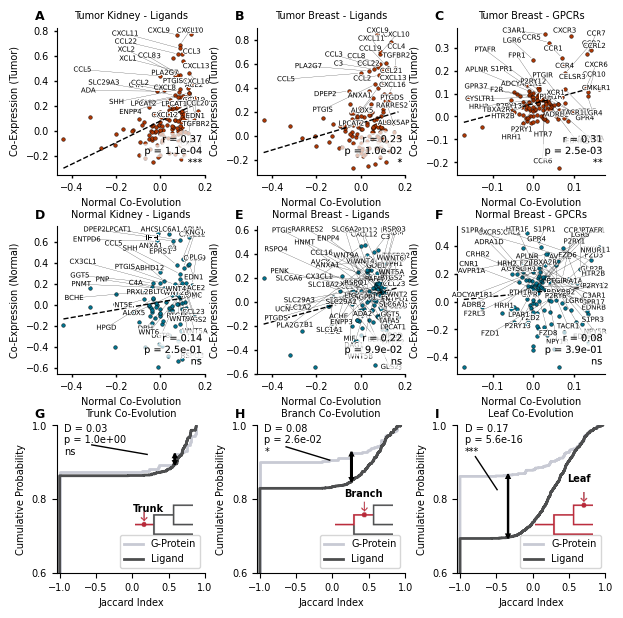

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import string
import matplotlib.patheffects as path_effects
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import os
from adjustText import adjust_text

fs = 7

############################################
# -------- MOSAIC --------
############################################

fig, axes = plt.subplot_mosaic(
    """
    ABC
    DEF
    GHI
    """,
    figsize=(7.08, 7.08),
    constrained_layout=False
)
plt.subplots_adjust(wspace=0.35, hspace=0.35)

############################################
# -------- CORRELATION PANELS (A–F) --------
############################################

tissue_category_pairs = [
    ('kidney','ligand'),
    ('breast','ligand'),
    ('breast','gpcr')
]

panel_map = [
    ['A','B','C'],  # tumor
    ['D','E','F']   # normal
]

for col_idx,(tissue,category) in enumerate(tissue_category_pairs):
    for row_idx,condition in enumerate(['tumor','normal']):
        ax = axes[panel_map[row_idx][col_idx]]
        
        if category in ['ligand','gprot']:
            groupby_col='interactor'
        elif category=='gpcr':
            groupby_col='gpcr'
        else:
            raise ValueError("Category must be ligand, gprot, or gpcr")

        r_col=f'{condition}_corr'
        p_col=f'{condition}_p'

        filtered=result_df[
            (result_df['type']==category) &
            (result_df['tissue']==tissue) &
            result_df[r_col].notna()
        ]

        ddf=df_original.copy()
        if category=='ligand':
            ddf=ddf.query('interactor_type=="Ligand"')
            name='Ligands'
        elif category=='gprot':
            ddf=ddf.query('interactor_type=="G-Protein"')
            name='G Proteins'
        else:
            name='GPCRs'

        coexpr=ddf.query(
            f'condition=="{condition.capitalize()} Co-Expression" and tissue==@tissue'
        ).groupby(groupby_col)['value'].mean()

        coev=ddf.query(
            'condition=="Normal Co-Evolution"'
        ).groupby(groupby_col)['value'].mean()

        shared=coexpr.index.intersection(coev.index)

        x=coev[shared]
        y=coexpr[shared]

        fit=np.polyfit(x,y,1)
        fit_fn=np.poly1d(fit)
        x_sorted=np.sort(x)

        ax.scatter(
            x,y,
            color=[tcolor,ncolor][row_idx],
            edgecolor='k',
            lw=0.3,
            alpha=1,
            s=7
        )

        ax.plot(x_sorted, fit_fn(x_sorted), color='black', linestyle='--', lw=1)

        # Quadrant labels
        xlim=ax.get_xlim()
        ylim=ax.get_ylim()
        x_thresh=np.mean(xlim)
        y_thresh=np.mean(ylim)
        upper_right=x[(x>x_thresh)&(y>y_thresh)].index

        texts=[]
        for label in upper_right:
            texts.append(
                ax.text(
                    x[label], y[label], label,
                    fontsize=fs-2,
                    color='k',
                    path_effects=[
                        path_effects.Stroke(linewidth=1.5,foreground='white'),
                        path_effects.Normal()
                    ]
                )
            )

        adjust_text(
            texts,
            ax=ax,
            explode=(4,4),
            expand=(1,1),
            force_text=(2.,2.),
            arrowprops=dict(arrowstyle='-',color='k',lw=0.15)
        )

        if not filtered.empty:
            r=filtered[r_col].values[0]
            p=filtered[p_col].values[0]

            if p<0.001: sgf='***'
            elif p<0.01: sgf='**'
            elif p<0.05: sgf='*'
            else: sgf='ns'

            ax.text(
                0.98,0.05,
                f"r = {r:.2f}\np = {p:.1e}\n{sgf}",
                transform=ax.transAxes,
                fontsize=fs,
                va='bottom',
                ha='right',
                color='k',
                path_effects=[
                    path_effects.Stroke(linewidth=7,foreground='white',alpha=0.7),
                    path_effects.Normal()
                ]
            )

        ax.set_title(f"{condition.title()} {tissue.title()} - {name}",fontsize=fs)
        #if row_idx==1: ax.set_xlabel("Co-Evolution (Orthology)",fontsize=fs)
        #if col_idx==0: ax.set_ylabel(f"Co-Expression ({condition.title()})",fontsize=fs)
        ax.set_xlabel("Normal Co-Evolution",fontsize=fs)
        ax.set_ylabel(f"Co-Expression ({condition.title()})",fontsize=fs)
            
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')
        ax.tick_params(length=2,width=1,labelsize=fs,direction='out')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

############################################
# -------- JACCARD PANELS (G–I, bottom row with icons) --------
############################################

jaccard_conditions = ['Trunk Co-Evolution', 'Branch Co-Evolution', 'Leaf Co-Evolution']
ks_stats=[]
p_vals=[]

for condition in ['Normal Co-Expression', 'Tumor Co-Expression', 'Normal Co-Evolution']:
    ks_stat, p_value=get_pvals_stats(df, condition)
    ks_stats.append(ks_stat)
    p_vals.append(p_value)

for condition in jaccard_conditions:
    ks_stat, p_value=get_pvals_stats(df, condition)
    ks_stats.append(ks_stat)
    p_vals.append(p_value)

corrected_pvals=false_discovery_control(p_vals)

ylim_jaccard=(0.6,1)
cdf_panels=['G','H','I']

# Icons setup
icons_path='/home/lnemati/pathway_crosstalk/data/coev_icons'
icon_files={'G':'trunk_reverse.png','H':'branch_reverse.png','I':'leaf_reverse.png'}
label_map={'G':'Trunk','H':'Branch','I':'Leaf'}
offsetx={'G':-0.1,'H':0,'I':0.1}
offsety={'G':-0.1,'H':0,'I':0.1}
icon_scaling_factor=0.13

for idx, condition in enumerate(jaccard_conditions):
    panel = cdf_panels[idx]
    
    plot_cdf_with_ks(
        df,
        condition,
        axes[panel],
        ks_stats[3+idx],
        corrected_pvals[3+idx],
        graycolor,
        lightgray,
        ylim=ylim_jaccard,
        xlim=(-1.04,1),
        text_coords=(0.05,0.9),
        text_ha='left'
    )
    
    # Panel title
    axes[panel].set_title(f"{condition}",fontsize=fs)
    axes[panel].set_xlabel('Jaccard Index', fontsize=fs)
    #axes[panel].set_xticks([0,0.5,1])
    axes[panel].set_yticks([0.6,0.8,1])

    # Add icons
    icon_path=os.path.join(icons_path,icon_files[panel])
    if os.path.exists(icon_path):
        icon=Image.open(icon_path)
        w,h=icon.size
        icon_resized=icon.resize((int(w*icon_scaling_factor), int(h*icon_scaling_factor)))
        imagebox=OffsetImage(np.array(icon_resized), zoom=0.5)
        ab=AnnotationBbox(imagebox, (0.72,0.4), xycoords='axes fraction', frameon=False)
        axes[panel].add_artist(ab)
        axes[panel].text(
            0.72+offsetx[panel],
            0.5+offsety[panel],
            label_map[panel],
            transform=axes[panel].transAxes,
            ha='center',
            va='bottom',
            fontsize=fs,
            fontweight='bold'
        )

############################################
# -------- PANEL LETTERS --------
############################################

for label,ax in axes.items():
    ax.text(
        -0.15,1.12,label,
        transform=ax.transAxes,
        fontsize=fs+2,
        fontweight='bold',
        va='top',
        ha='left'
    )

    #plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/supplementary/gpcrs_nonsynonym_and_scatterplot.png', bbox_inches='tight', dpi=300)
    #plt.savefig('/home/lnemati/pathway_crosstalk/results/supplementary/gpcrs_nonsynonym_and_scatterplot.pdf', bbox_inches='tight', dpi=300)

# -----------------------------
# Save
# -----------------------------
name = 'S2'
figures_dir = '/home/lnemati/pathway_crosstalk/results/figures/new_figures'
os.makedirs(os.path.join(figures_dir, name), exist_ok=True)

plt.savefig(os.path.join(figures_dir, name, name) + '.pdf', bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(figures_dir, name, name) + '.png', bbox_inches='tight', dpi=300)
    
plt.show()

In [65]:
fig_to_panels(fig, axes, output_dir='/home/lnemati/pathway_crosstalk/results/figures/new_figures/S2/panels')

Saved panel 'Tumor Kidney - Ligands' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/S2/panels/tumor_kidney_-_ligands
Saved panel 'Tumor Breast - Ligands' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/S2/panels/tumor_breast_-_ligands
Saved panel 'Tumor Breast - GPCRs' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/S2/panels/tumor_breast_-_gpcrs
Saved panel 'Normal Kidney - Ligands' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/S2/panels/normal_kidney_-_ligands
Saved panel 'Normal Breast - Ligands' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/S2/panels/normal_breast_-_ligands
Saved panel 'Normal Breast - GPCRs' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/S2/panels/normal_breast_-_gpcrs
Saved panel 'Trunk Co-Evolution' to /home/lnemati/pathway_crosstalk/results/figures/new_figures/S2/panels/trunk_co-evolution
Saved panel 'Branch Co-Evolution' to /home/lnemati/pathway_crosstalk/results/fi

In [68]:
#result_df.to_csv('/home/lnemati/pathway_crosstalk/results/supplementary/gene_scores.csv')